## Assignment 2: $k$ Nearest Neighbor

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

Regression is used when the thing we’re predicting is a number (continuous), like price or temperature.
Classification is used when we’re predicting a category or label (like mine_type or whether someone dies or survives).

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion matrix compares the actual class to the predicted class. The diagonal shows correct predictions, and the off-diagonal values show where the model is making mistakes. It helps us understand what kinds of errors the model makes, not just how many.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy is the proportion of predictions that are correct. Accuracy alone isn’t always enough because:
- If one class is much bigger than the others, a model can look accurate but still be bad.
- It doesn’t show which classes are being confused.
- Some mistakes matter more than others depending on the situation.

4. What does the root mean squared error quantify about a particular model?

Root Mean Squared Error measures the average size of prediction errors in regression. Lower RMSE means predictions are closer to the real values. It basically tells us how far off our model is, on average.

5. What are overfitting and underfitting?

- Underfitting: model is too simple so it misses patterns which leads to bad performance overall.
- Overfitting: model learns noise in the training data so it does great on the training set but bad on the test set.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

If we only evaluate on training data, we might think the model is better than it actually is. Splitting data lets us train on one part and evaluate on unseen data.
Choosing $k$ based on test performance helps find the model that generalizes best, not just memorizes.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Class label prediction
- Simple and easy to interpret.
- But hides uncertainty.

Probability prediction
- Shows confidence (ex: 70% class A, 30% class B).
- More flexible for decision-making.
- But harder to interpret quickly.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [97]:
import pandas as pd

df = pd.read_csv('land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


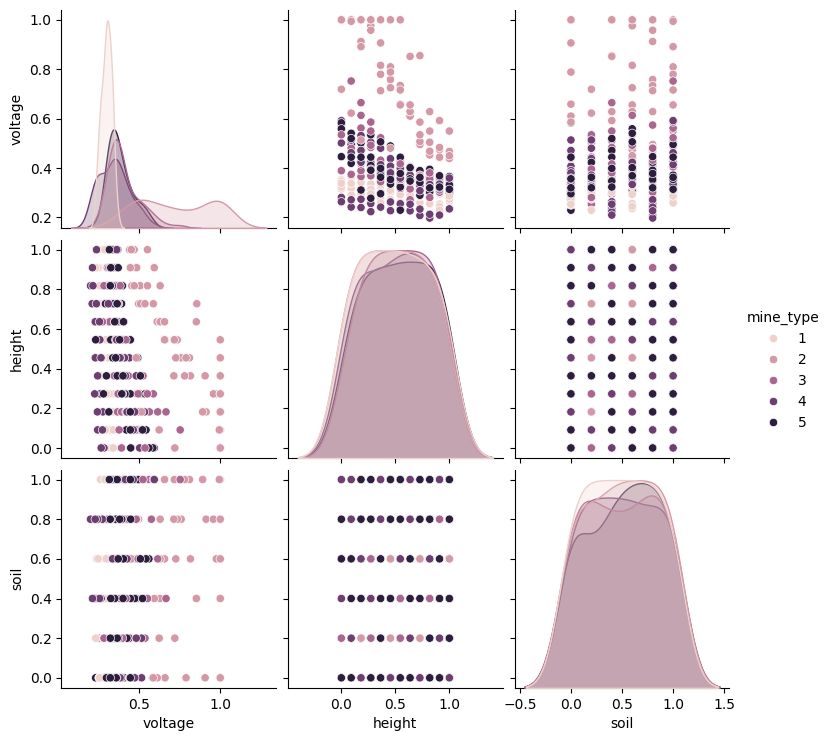

In [98]:
import seaborn as sns

sns.pairplot(df, hue='mine_type')

Observations: The pair plot shows that the mine types overlap quite a bit across all features, so I do not expect perfect classification performance. Voltage appears to provide the clearest separation between classes since some mine types reach higher voltage values than others. Height and soil show much more overlap, suggesting they are weaker predictors individually. The scatterplots also show a slight negative relationship between voltage and height, but the separation between classes is still limited overall.

In [99]:
from sklearn.model_selection import train_test_split

X = df[['voltage','height','soil']] #features
y = df['mine_type'] #target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)

In [100]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in [1,2,3,4,5]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(k, accuracy_score(y_test,preds))

1 0.3254437869822485
2 0.40236686390532544
3 0.3905325443786982
4 0.33727810650887574
5 0.3431952662721893


I tested multiple values of k and compared their test accuracy. The best performance occurred at k = 2 with an accuracy of about 40%.

In [101]:
model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("accuracy_score:", acc)

accuracy_score: 0.40236686390532544


In [103]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

print(cm)
print("manual accuracy:", cm.trace()/cm.sum())

[[18  1 12  3  1]
 [ 0 29  1  5  0]
 [ 7  1 16  8  1]
 [15  5 10  3  0]
 [14  1 14  2  2]]
manual accuracy: 0.40236686390532544


Accuracy was calculated by summing the diagonal of the confusion matrix (68 correct predictions) and dividing by the total number of observations (169), giving an accuracy of about 40%. The model performs best for mine type 2, correctly classifying 29 out of 35 observations in that class. However, performance is much worse for mine types 4 and 5, where only 3 and 2 observations respectively are correctly predicted. Even though the model predicts some mine types accurately, it still makes many mistakes overall. Because of this, I would not rely on it as a final decision tool. Instead, I would use it as a support system to help narrow down possible mine types. Predictions that the model is more confident about could be prioritized, but uncertain predictions should be reviewed by a human. In a high-risk situation like land mine detection, human verification would still be necessary to reduce dangerous errors.

Accuracy from accuracy_score matched the manual confusion-matrix calculation (diagonal / total), confirming the result.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [68]:
import pandas as pd

df = pd.read_csv('USA_cars_datasets.csv')
df = df[['price','year','mileage']]
#df.isna().sum() #there aren't any NA's to handle
print(df.shape) #data dimension
df.head()

(2499, 3)


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [70]:
X = df[['year','mileage']]
y = df['price']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)
X_test  = (X_test  - train_min) / (train_max - train_min)

In [75]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

for k in [3,10,25,50,100,300]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test,pred)
    print(k, mse)

3 144064589.90111113
10 117051744.24386002
25 108677153.0502048
50 107439120.76638879
100 107052538.8945762
300 109848437.53711972


As k increased, the model became smoother and less sensitive to individual points. The test MSE decreased as k increased up to k=100, then increased slightly at k=300, suggesting that very large k values begin to underfit. The best value was k = 100 because it had the lowest MSE. Small k values showed overfitting, while very large k values showed underfitting.

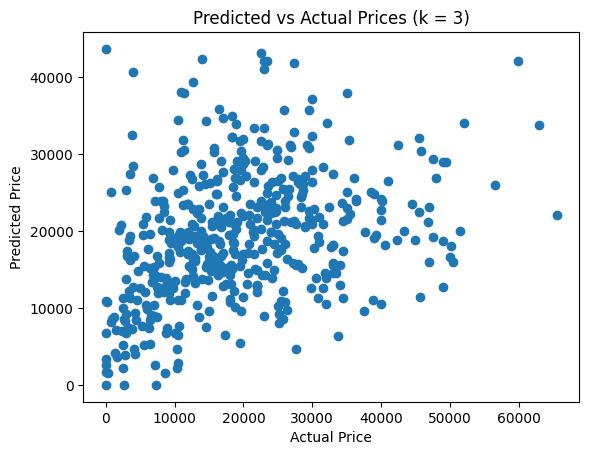

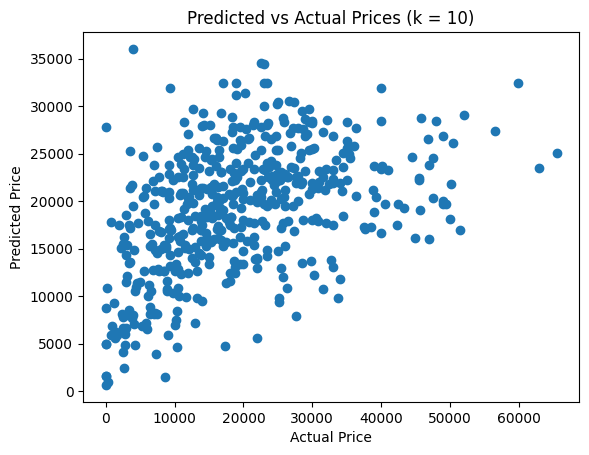

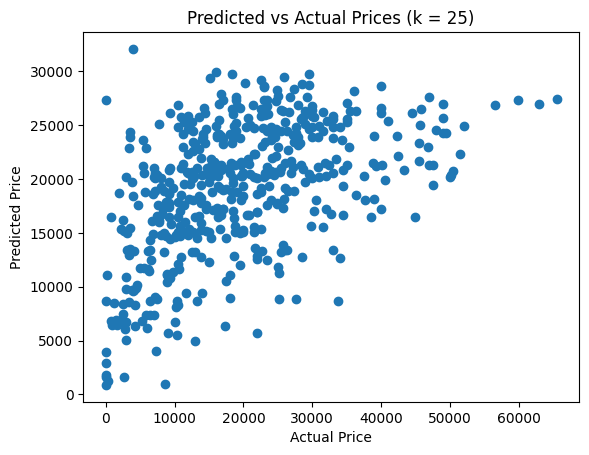

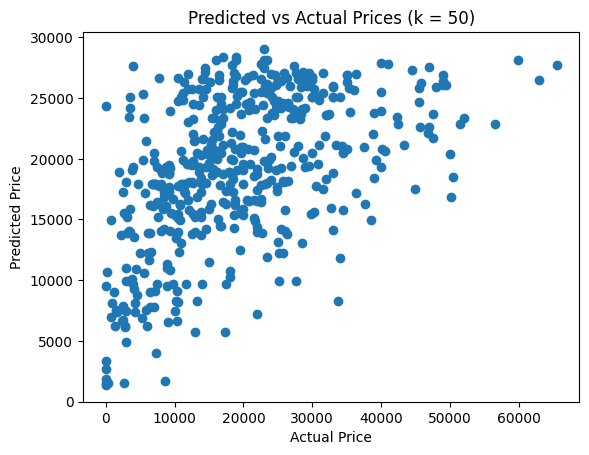

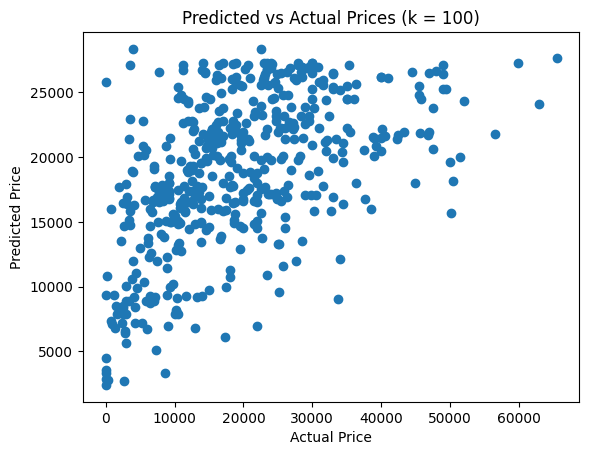

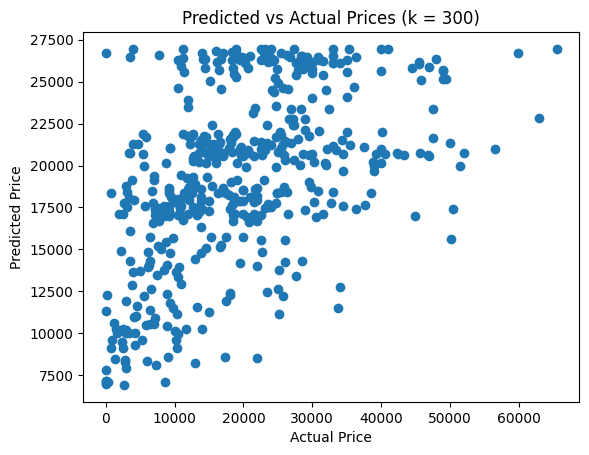

In [76]:
import matplotlib.pyplot as plt

k_values = [3, 10, 25, 50, 100, 300]

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    plt.scatter(y_test, preds)
    plt.title(f"Predicted vs Actual Prices (k = {k})")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()

In the predicted vs actual price plots, smaller values of k produced more scattered predictions, meaning the model reacted strongly to local variation and showed signs of overfitting. As k increased, the predictions became smoother and less variable. For very large values of k, the predicted prices were compressed into a narrower range and high-price cars were underestimated, showing underfitting because the model averaged too many neighbors.

Based on test MSE, the optimal value was k=100. Visually, smaller k values looked noisier (overfitting), while very large k values (like 300) produced more compressed predictions (underfitting). The choice k=100 balanced these effects and gave the lowest test error. Even though the k=100 scatterplot still shows some compression for very expensive cars, it minimizes average squared error across the test set.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [77]:
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df = df.drop(columns=['time'])

#df.head()
df.isna().sum() # there are not any NA's to handle

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


<Axes: >

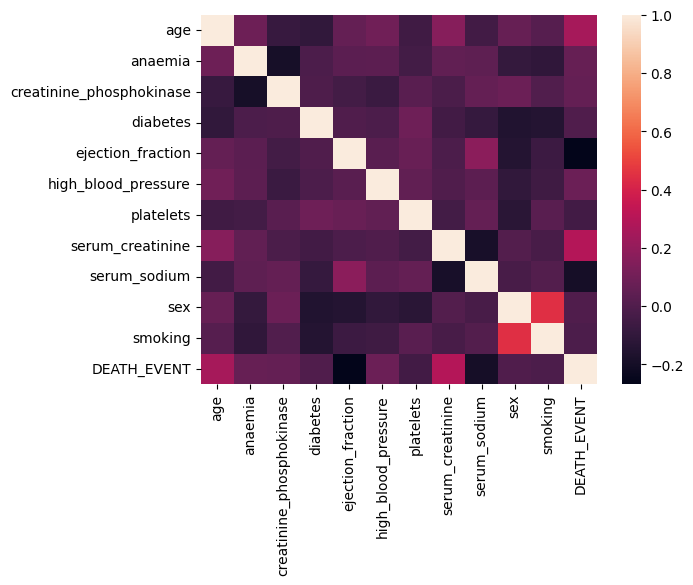

In [78]:
import seaborn as sns

df.corr()
sns.heatmap(df.corr())

Variables with strongest correlation to DEATH_EVENT:
- serum_creatinine
- age

In [79]:
df.groupby('anaemia')['DEATH_EVENT'].mean()

,DEATH_EVENT
anaemia,
0,0.294118
1,0.356589


In [80]:
df.groupby('diabetes')['DEATH_EVENT'].mean()

,DEATH_EVENT
diabetes,
0,0.321839
1,0.320000


In [81]:
df.groupby('high_blood_pressure')['DEATH_EVENT'].mean()

,DEATH_EVENT
high_blood_pressure,
0,0.293814
1,0.371429


In [82]:
df.groupby('sex')['DEATH_EVENT'].mean()

,DEATH_EVENT
sex,
0,0.323810
1,0.319588


In [83]:
df.groupby('smoking')['DEATH_EVENT'].mean()

,DEATH_EVENT
smoking,
0,0.325123
1,0.312500


Which variables have higher death rate when =1.
- high_blood_pressure
- anaemia

In [84]:
X = df[['serum_creatinine','age','high_blood_pressure','anaemia']]
y = df['DEATH_EVENT']

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)
X_test  = (X_test  - train_min) / (train_max - train_min)

In [87]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

for k in range(1,11):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = mse**0.5
    print(k, mse, rmse)

1 0.43333333333333335 0.6582805886043833
2 0.24583333333333332 0.4958158260214505
3 0.23333333333333334 0.48304589153964794
4 0.203125 0.45069390943299864
5 0.214 0.4626013402488151
6 0.18935185185185185 0.43514578229813033
7 0.17687074829931976 0.42056004125370705
8 0.17604166666666668 0.4195731958391368
9 0.17983539094650206 0.4240700307101435
10 0.17899999999999996 0.42308391602612355


8 has the lowest value of error.

In [91]:
X = df.drop(columns=['DEATH_EVENT'])
y = df['DEATH_EVENT']

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)
X_test  = (X_test  - train_min) / (train_max - train_min)

In [94]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

for k in range(1,11):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = mse**0.5
    print(k, mse, rmse)

1 0.26666666666666666 0.5163977794943222
2 0.25 0.5
3 0.20185185185185184 0.4492792582034606
4 0.20208333333333334 0.44953679864203927
5 0.20800000000000002 0.4560701700396552
6 0.19351851851851853 0.4399073976628701
7 0.1717687074829932 0.4144498853697431
8 0.17395833333333333 0.4170831252080733
9 0.17572016460905354 0.41918989087173075
10 0.16916666666666663 0.4112987559751022


10 has the lowest value of error.

I compared a k-NN model using selected predictors (based on the correlation matrix and group summaries) to a model using all available predictors except time. I kept the same train/test split for both models and used min–max normalization based on the training set to make the distance calculations comparable. Using RMSE (as requested), the selected-variable model performed best at k=8 with RMSE ≈0.42, while the all-variable model performed best at k=10 with RMSE ≈0.41. Although the all-variable model was slightly better, the improvement was very small (~0.01 RMSE), suggesting that adding more variables does not necessarily help k-NN. In practice I would prefer the simpler model unless the small RMSE gain is worth the added complexity, since extra variables can add noise and make distances less informative (curse of dimensionality).